# **Lab 2. Шаврин Алексей Павлович гр. 1306**

# Установка зависимостей

In [ ]:
!pip install opencv-python-headless matplotlib

# Импорт

In [32]:
import zipfile
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import random

# Загрузка параметров калибровки

In [2]:
calib_data = np.load('calibration_data.npz')
K = calib_data['mtx']
dist = calib_data['dist']
print("Матрица камеры:\n", K)
print("dist:\n", dist)

Матрица камеры:
 [[6.05304386e+03 0.00000000e+00 2.54106629e+03]
 [0.00000000e+00 6.03790770e+03 1.30293216e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
dist:
 [[-1.75617506e-01  3.62500930e+00  3.27014252e-03  3.28190351e-03
  -2.11790275e+01]]


# Загрузка данных

In [3]:
with zipfile.ZipFile('Фото.zip', 'r') as zip_ref:
    zip_ref.extractall('photos')

In [4]:
image_paths = glob.glob('photos/*.JPG')[:2]
image_paths.sort()
print(image_paths)

['photos/DSC02692.JPG', 'photos/DSC02694.JPG']


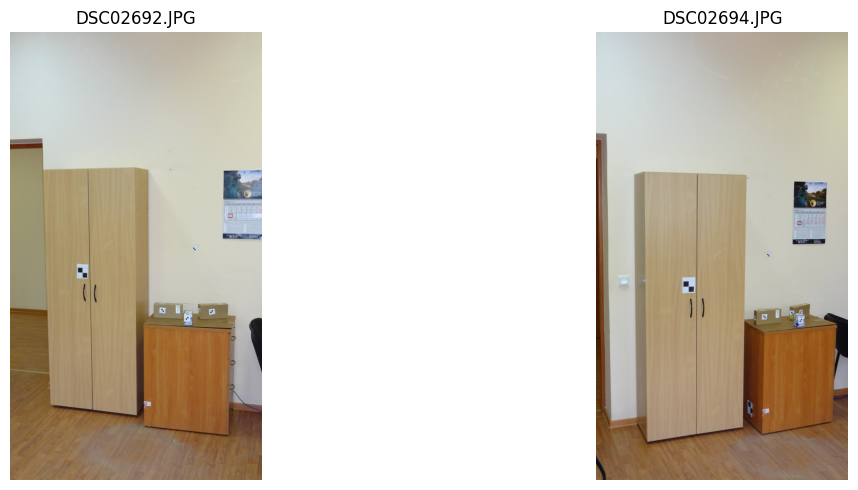

Загружено 2 изображений


In [21]:
images = []   # изображения
names = []    # имена файлов

plt.figure(figsize=(15, 5))
for i, path in enumerate(image_paths):
    img = cv2.imread(path)
    if img is None:
        print(f"Не удалось загрузить {path}")
        continue
    img_name = path.split('/')[-1]
    names.append(img_name)
    images.append(img)

    # визуализация загруженных фото
    plt.subplot(1, 2, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(img_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Загружено {len(images)} изображений")

# Поиск и сопоставление SIFT-признаков (ключевые точки и их дескрипторы)

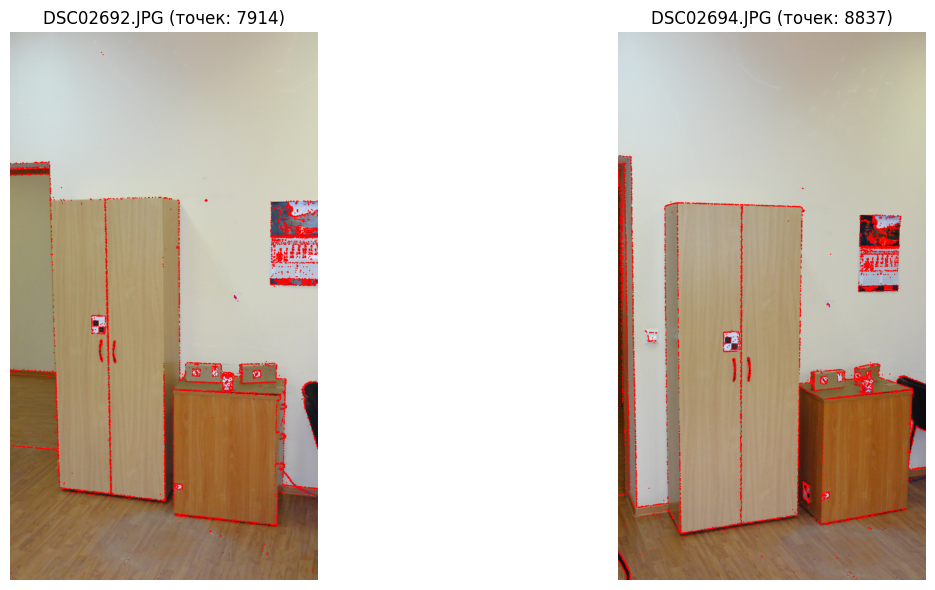

In [24]:
sift = cv2.SIFT_create()
kps = []          # ключевые точки
descs = []        # дескрипторы

plt.figure(figsize=(15, 6))
for i, (img, name) in enumerate(zip(images, names)):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kp, d = sift.detectAndCompute(gray, None)
    kps.append(kp)
    descs.append(d)

    # визуализация ключевыз точек
    img_with_kp = img.copy()
    for point in kp:
        x, y = int(point.pt[0]), int(point.pt[1])
        cv2.circle(img_with_kp, (x, y), 5, (0, 0, 255), -1)

    plt.subplot(1, 2, i+1)
    plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
    plt.title(f"{name} (точек: {len(kp)})")
    plt.axis('off')

plt.tight_layout()
plt.show()

# FLANN matcher

In [26]:
FLANN_INDEX_KDTREE = 1  # использует k‑dimensional tree для SIFT признаков
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(descs[0], descs[1], k=2)

# Применяем Lowe's ratio test

In [33]:
def draw_matches_thick(img1, kp1, img2, kp2, matches, thickness=4):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    result = np.hstack((img1, img2))
    for m in matches:
        color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
        x1, y1 = int(kp1[m.queryIdx].pt[0]), int(kp1[m.queryIdx].pt[1])
        x2, y2 = int(kp2[m.trainIdx].pt[0]) + w1, int(kp2[m.trainIdx].pt[1])
        cv2.line(result, (x1, y1), (x2, y2), color, thickness)
    return result

In [47]:
good = [m for m, n in matches if m.distance < 0.7 * n.distance]

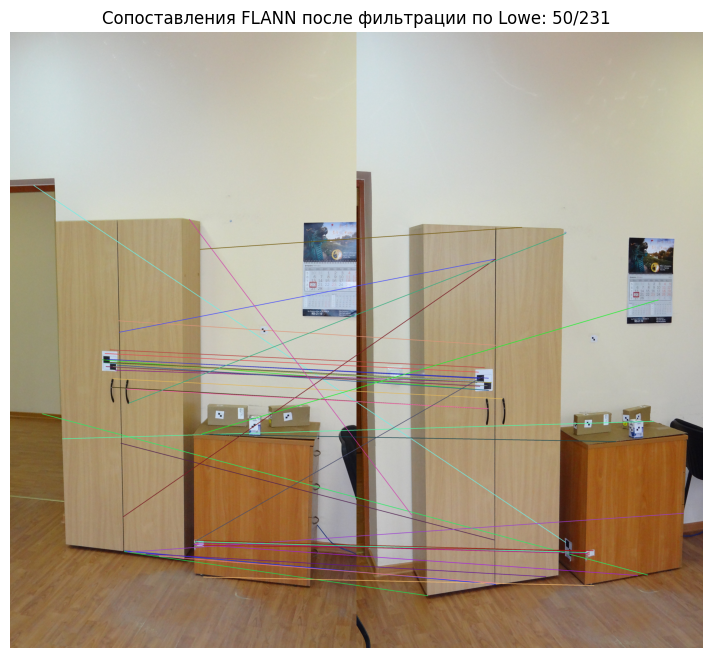

In [48]:
count_shown_good = min(50, len(good))

img_matches = draw_matches_thick(
    images[0], kps[0], images[1], kps[1],
    good[:count_shown_good]
)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title(f"Сопоставления FLANN после фильтрации по Lowe: {count_shown_good}/{len(good)}")
plt.axis('off')
plt.show()

# Вычисление координат соответствий

In [40]:
pts = [
    np.float32([kps[0][m.queryIdx].pt for m in good]).reshape(-1, 1, 2),
    np.float32([kps[1][m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
]

# Вычисляем существенную матрицу и inliers

In [52]:
E, mask = cv2.findEssentialMat(
    pts[0],
    pts[1],
    K,
    method=cv2.RANSAC,
    prob=0.999,
    threshold=1.0
)
inlier_pts = [p[mask.ravel() == 1] for p in pts]

inlier_matches = [good[i] for i in range(len(good)) if mask[i]]

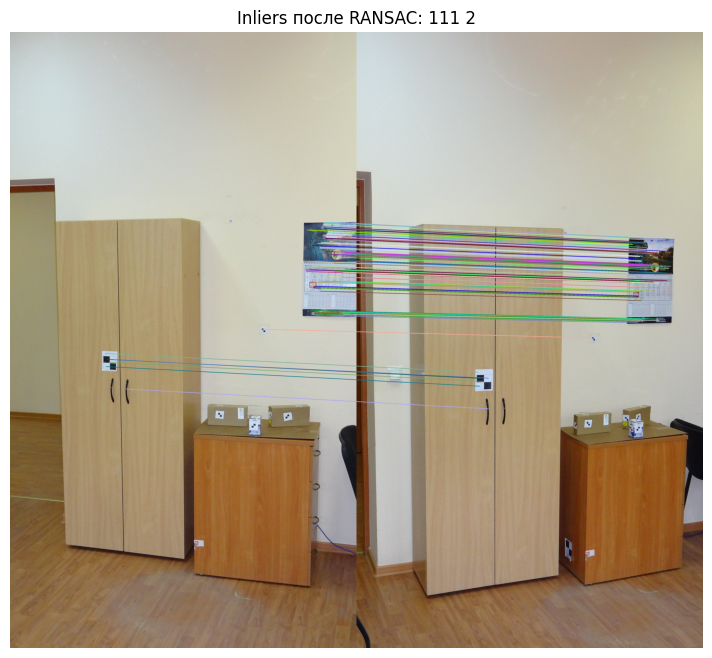

In [53]:
img_inliers = draw_matches_thick(images[0], kps[0], images[1], kps[1], inlier_matches)
plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(img_inliers, cv2.COLOR_BGR2RGB))
plt.title(f"Inliers после RANSAC: {len(inlier_matches)}")
plt.axis('off')
plt.show()

# Восстанавливаем R, t (без масштаба)

In [98]:
_, R, t, _ = cv2.recoverPose(E, inlier_pts[0], inlier_pts[1], K)
print("\nМатрица поворота R")
print(R)
print("\nВектор смещения t")
print(t)


Матрица поворота R
[[ 0.73479262 -0.07510737 -0.67412068]
 [ 0.07618446  0.99670034 -0.0280065 ]
 [ 0.67399981 -0.03077855  0.73809006]]

Вектор смещения t
[[0.8619276 ]
 [0.07421435]
 [0.50157057]]


# Строим проекционные матрицы для двух камер

In [99]:
P1 = K @ np.hstack((np.eye(3), np.zeros((3,1))))
P2 = K @ np.hstack((R, t))
print("P1:\n", P1)
print("P2:\n", P2)

P1:
 [[6.05304386e+03 0.00000000e+00 2.54106629e+03 0.00000000e+00]
 [0.00000000e+00 6.03790770e+03 1.30293216e+03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00]]
P2:
 [[ 6.16041011e+03 -5.32838542e+02 -2.20494629e+03  6.49180966e+03]
 [ 1.33817077e+03  5.97788228e+03  7.92580612e+02  1.10161179e+03]
 [ 6.73999807e-01 -3.07785511e-02  7.38090062e-01  5.01570568e-01]]


# Координаты углов шкафа на двух изображениях (порядок: верх-левый, верх-правый, низ-левый, низ-правый) (полученны вручную через gimp)

In [128]:
cabs = [
  np.array([[360, 1506], [1365, 1480], [1385, 4188], [445, 4070]], dtype=np.float32),
  np.array([[530, 1530], [1644, 1567], [1605, 4318], [565, 4480]], dtype=np.float32)
]

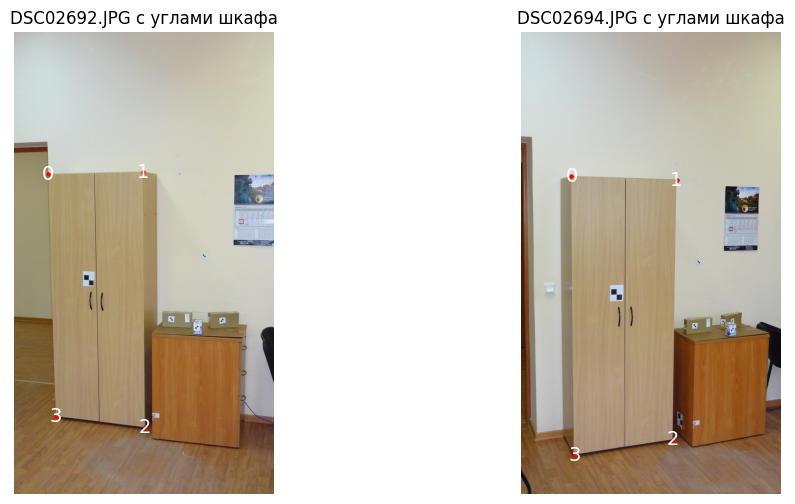

In [127]:
plt.figure(figsize=(12,6))

for i, (name, image) in enumerate(zip(names, images)):
  plt.subplot(1,2,i+1)
  plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  plt.scatter(cabs[i][:,0], cabs[i][:,1], c='red', s=5, marker='o')
  for j, (x, y) in enumerate(cabs[i]):
      plt.text(x, y, str(j), color='white', fontsize=14, ha='center', va='center')
  plt.title(f"{name} с углами шкафа")
  plt.axis('off')
plt.show()

# Триангуляция шкафа

In [137]:
points4d = cv2.triangulatePoints(P1, P2, cabs[0].T, cabs[1].T)
points3d = (points4d[:3] / points4d[3]).T

# Координаты двери (верх и низ) на двух изображениях (полученны вручную через gimp)

In [130]:
doors = [
    np.array([[354, 1162], [440, 3900]], dtype=np.float32),
    np.array([[115, 1110], [170, 4315]], dtype=np.float32)
]

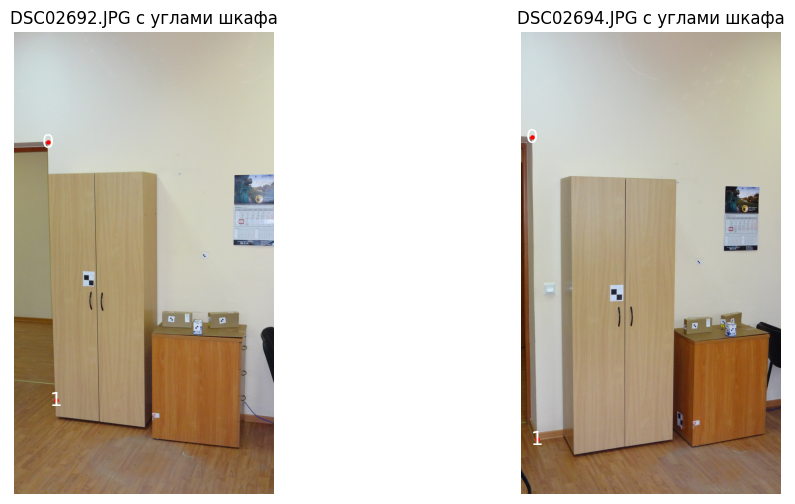

In [142]:
plt.figure(figsize=(12,6))

for i, (name, image) in enumerate(zip(names, images)):
  plt.subplot(1,2,i+1)
  plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  plt.scatter(doors[i][:,0], doors[i][:,1], c='red', s=5, marker='o')
  for j, (x, y) in enumerate(doors[i]):
      plt.text(x, y, str(j), color='white', fontsize=14, ha='center', va='center')
  plt.title(f"{name} с углами шкафа")
  plt.axis('off')
plt.show()

# Триангуляция двери

In [131]:
door4d = cv2.triangulatePoints(P1, P2, doors[0].T, doors[1].T)
door3d = (door4d[:3] / door4d[3]).T

# Определение масштаба по эталонному объекту (двери)

In [134]:
door_height = np.linalg.norm(door3d[1] - door3d[0])
real_door = 2000
scale = real_door / door_height
print("Высота двери в у.е: ", door_height)
print("Реальная высота двери в мм: ", real_door)
print("Коэффициент масштаба: ", scale)

Высота двери в у.е:  0.6287207
Реальная высота двери в мм:  2000
Коэффициент масштаба:  3181.0627


# Масштабируем 3D-точки шкафа

In [138]:
print(points3d)

[[-0.47690883  0.04365229  1.3235497 ]
 [-0.24946357  0.03725201  1.2839522 ]
 [-0.23696452  0.5953167   1.2388765 ]
 [-0.44267398  0.58814126  1.2775619 ]]


In [139]:
points3d *= scale

In [140]:
print(points3d)

[[-1517.0769    138.86067  4210.295  ]
 [ -793.55927   118.50097  4084.3325 ]
 [ -753.799    1893.7397   3940.9438 ]
 [-1408.1737   1870.9143   4064.0046 ]]


# Вычисляем ширину и высоту шкафа (расстояния между соответствующими углами)

In [141]:
width = np.linalg.norm(points3d[1] - points3d[0])
height = np.linalg.norm(points3d[2] - points3d[1])
print("Размеры шкафа:")
print(f"Ширина: {width} мм")
print(f"Высота: {height} мм")

Размеры шкафа:
Ширина: 734.6828002929688 мм
Высота: 1781.4639892578125 мм
